# HW4-Q1 火星内核射线追踪（作业版）

本笔记本围绕题目要求完成 4 件事：

1. 构建两套 1D 火星速度模型（无固态内核 / 有固态内核）。
2. 在震源深度 33 km、震中距 27° 下绘制射线路径对比图（对应 Fig1a/Fig1b 思路）。
3. 对比两套模型的可见震相与走时，量化固态内核带来的影响（秒）。
4. 给出结果解释，并整理为可直接写入作业报告的结论。

说明：
- 这里采用教学参数化模型，用于机制验证与作业复现。
- 目标是“现象和物理解释一致”，不是逐点复刻 Nature 反演模型的全部细节。
- 图件与表格均保存在当前作业目录下，便于提交与复查。

In [110]:
# 如果缺包，请先运行：%pip install obspy matplotlib pandas numpy

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy.taup import TauPyModel
from obspy.taup.taup_create import build_taup_model

# Matplotlib 中文显示兼容设置（按顺序尝试系统可用字体）
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

# 题目给定参数
MARS_RADIUS_KM = 3389.0
SOURCE_DEPTH_KM = 33.0
DISTANCE_DEG = 27.0

# 目录设置：模型文件统一写入 models，图统一写入 figures
work_dir = Path(".")
model_dir = work_dir / "models"
model_dir.mkdir(parents=True, exist_ok=True)

print(f"工作目录: {work_dir.resolve()}")
print(f"模型目录: {model_dir.resolve()}")
print(f"震源深度 = {SOURCE_DEPTH_KM} km, 震中距 = {DISTANCE_DEG}°")

工作目录: D:\GitHub\solid_physics\HW4
模型目录: D:\GitHub\solid_physics\HW4\models
震源深度 = 33.0 km, 震中距 = 27.0°


In [111]:
# ---------- 1) 构建两套火星 1D 速度模型（多层离散化） ----------

# 模型 A：无固态内核（整核液态）
nd_no_ic = """0.0       4.00    2.20    3.00
50.0      4.00    2.20    3.00
mantle
50.0      6.80    3.90    3.30
400.0     7.10    4.10    3.40
1000.0    7.30    4.20    3.50
1590.5    7.50    4.30    3.60
outer-core
1590.5    4.90    0.00    6.00
2000.0    5.10    0.00    6.20
2400.0    5.30    0.00    6.35
2800.0    5.50    0.00    6.50
3389.5    5.80    0.00    6.80
"""

# 模型 B：有固态内核（内核半径约 613 km，ICB 深度 2776.5 km）
nd_ic = """0.0       4.00    2.20    3.00
50.0      4.00    2.20    3.00
mantle
50.0      6.80    3.90    3.30
400.0     7.10    4.10    3.40
1000.0    7.30    4.20    3.50
1590.5    7.50    4.30    3.60
outer-core
1590.5    4.90    0.00    6.00
2000.0    5.10    0.00    6.20
2400.0    5.30    0.00    6.35
2776.5    5.50    0.00    6.50
inner-core
2776.5    7.15    3.50    8.00
3389.5    7.30    3.60    8.20
"""

def build_model_from_nd(nd_text: str, model_name: str) -> Path:
    """将 ND 文本写入 models 目录并编译为 TauP 可读的 NPZ 模型。"""
    nd_path = model_dir / f"{model_name}.nd"
    npz_path = model_dir / f"{model_name}.npz"

    nd_path.write_text(nd_text.strip(), encoding="utf-8")
    build_taup_model(str(nd_path), output_folder=str(model_dir), verbose=False)
    return npz_path

# 编译两套模型
npz_no_path = build_model_from_nd(nd_no_ic, "mars_no_ic")
npz_ic_path = build_model_from_nd(nd_ic, "mars_ic")

# 某些环境下 TauP 可能在根目录留下同名副本，统一清理避免目录污染
for stale_name in ["mars_no_ic.nd", "mars_no_ic.npz", "mars_ic.nd", "mars_ic.npz"]:
    stale_path = work_dir / stale_name
    if stale_path.exists():
        stale_path.unlink()

print("✓ 模型编译完成（多层离散化）")
print(f"  - {npz_no_path}")
print(f"  - {npz_ic_path}")
print("✓ 根目录同名副本已清理，仅保留 models 下文件")

✓ 模型编译完成（多层离散化）
  - models\mars_no_ic.npz
  - models\mars_ic.npz
✓ 根目录同名副本已清理，仅保留 models 下文件


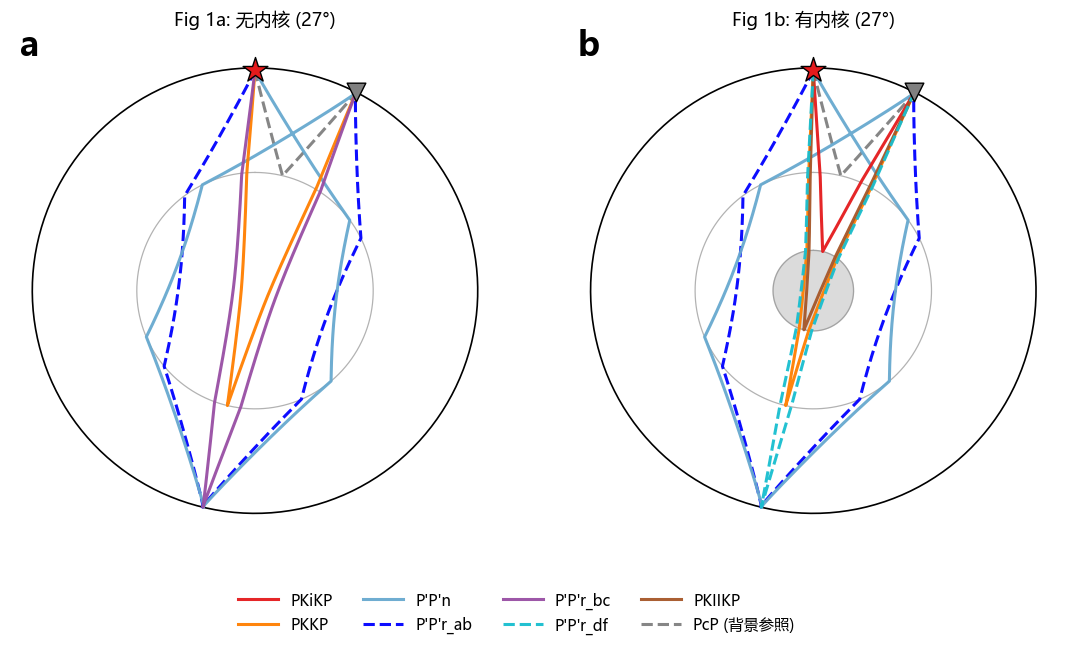

27° 主图可见相位：
  无内核: ['PKKP', 'PKPPKP', 'PcP']
  有内核: ['PKIIKP', 'PKIKKIKP', 'PKIKPPKIKP', 'PKPPKP', 'PKiKP', 'PcP']
PKPPKP 分类数量（无内核）: n=1, bc=1, ab=1
PKPPKP 分类数量（有内核）: n=1, bc=0, ab=1
解释：有内核模型在 27° 下仅保留优弧浅支（ab），bc 分支在该距离缺失或不可分辨。
✓ 最终主图已保存: figures\mars_ray_paths_final.png


In [112]:
# ---------- 2) 27° 条件下的射线路径主图（对应 Fig1a / Fig1b） ----------

model_no_ic = TauPyModel(model=str((model_dir / "mars_no_ic.npz").resolve()))
model_ic = TauPyModel(model=str((model_dir / "mars_ic.npz").resolve()))

source_depth_km = SOURCE_DEPTH_KM
distance_deg = DISTANCE_DEG

# 圈层深度（km）
CMB_DEPTH = 1590.5
ICB_DEPTH = 2776.5

# 相位池：无内核和有内核分开设置，便于后续对比
phase_pool_no_ic = ["PcP", "PKKP", "PKPPKP"]
phase_pool_ic = ["PcP", "PKiKP", "PKIIKP", "PKIKKIKP", "PKKP", "PKPPKP", "PKIKPPKIKP"]

arrivals_no_ic = model_no_ic.get_ray_paths(
    source_depth_in_km=source_depth_km,
    distance_in_degree=distance_deg,
    phase_list=phase_pool_no_ic,
)
arrivals_ic = model_ic.get_ray_paths(
    source_depth_in_km=source_depth_km,
    distance_in_degree=distance_deg,
    phase_list=phase_pool_ic,
)


def classify_pkppkp_branches(arrivals):
    """
    对 PKPPKP 做两阶段分类：
    1) 先按 end_deg 区分 n 分支（<180）与优弧家族（>180）；
    2) 再按最大下潜深度，将优弧家族区分为 bc / ab。
    """
    n_branch_ids = set()  # end_deg < 180
    abbc_candidates = []  # end_deg > 180
    diagnostics = []

    for arr in arrivals:
        if arr.name != "PKPPKP":
            continue

        end_deg = (float(arr.path["dist"][-1]) * 180.0 / np.pi) % 360.0
        max_depth = float(np.max(arr.path["depth"]))

        diagnostics.append({
            "arr_id": id(arr),
            "end_deg": round(end_deg, 3),
            "max_depth": round(max_depth, 3),
        })

        if end_deg < 180.0:
            n_branch_ids.add(id(arr))
        else:
            abbc_candidates.append((arr, max_depth))

    # 对优弧家族按下潜深度降序排序：更深者优先判作 bc
    abbc_candidates.sort(key=lambda x: x[1], reverse=True)

    bc_branch_ids = set()
    ab_branch_ids = set()

    # 若优弧仅 1 条，不强行标 bc，记作 ab（表示 bc 在该距离缺失/不可分辨）
    if len(abbc_candidates) >= 2:
        bc_branch_ids.add(id(abbc_candidates[0][0]))
        for arr, _ in abbc_candidates[1:]:
            ab_branch_ids.add(id(arr))
    elif len(abbc_candidates) == 1:
        ab_branch_ids.add(id(abbc_candidates[0][0]))

    class_map = {}
    for d in diagnostics:
        aid = d["arr_id"]
        if aid in n_branch_ids:
            cls = "P'P'n"
        elif aid in bc_branch_ids:
            cls = "P'P'r_bc"
        elif aid in ab_branch_ids:
            cls = "P'P'r_ab"
        else:
            cls = "unclassified"
        class_map[aid] = cls

    return n_branch_ids, bc_branch_ids, ab_branch_ids, diagnostics, class_map


def plot_final_rays(arrivals, ax, has_inner_core=False):
    """绘制单个模型的极坐标投影射线路径图。"""
    r_mars = MARS_RADIUS_KM
    r_cmb = MARS_RADIUS_KM - CMB_DEPTH
    r_icb = MARS_RADIUS_KM - ICB_DEPTH

    # 背景圈层
    theta_circle = np.linspace(0, 2 * np.pi, 300)
    ax.plot(r_mars * np.sin(theta_circle), r_mars * np.cos(theta_circle), color="black", lw=1.2, zorder=1)
    ax.plot(r_cmb * np.sin(theta_circle), r_cmb * np.cos(theta_circle), color="gray", lw=0.9, alpha=0.6, zorder=1)

    if has_inner_core:
        ax.plot(r_icb * np.sin(theta_circle), r_icb * np.cos(theta_circle), color="gray", lw=0.9, alpha=0.6, zorder=1)
        ax.fill(r_icb * np.sin(theta_circle), r_icb * np.cos(theta_circle), color="lightgray", alpha=0.8, zorder=0)

    n_ids, bc_ids, ab_ids, diagnostics, class_map = classify_pkppkp_branches(arrivals)

    legend_handles = {}
    plotted_labels = set()

    for arr in arrivals:
        name = arr.name
        dist_rad = np.asarray(arr.path["dist"], dtype=float)
        depth_km = np.asarray(arr.path["depth"], dtype=float)

        # end_deg > 180 的优弧分支镜像到左侧，便于与 n 分支并置对照
        end_deg = (dist_rad[-1] * 180.0 / np.pi) % 360.0
        if end_deg > 180.0:
            dist_rad = -dist_rad

        r = r_mars - depth_km
        x, y = r * np.sin(dist_rad), r * np.cos(dist_rad)

        if name == "PKPPKP":
            if id(arr) in n_ids:
                style = {"color": "#67a9cf", "ls": "-", "label": "P'P'n", "z": 4}
            elif id(arr) in bc_ids:
                style = {"color": "#984ea3", "ls": "-", "label": "P'P'r_bc", "z": 5}
            elif id(arr) in ab_ids:
                style = {"color": "blue", "ls": "--", "label": "P'P'r_ab", "z": 4}
            else:
                style = {"color": "#984ea3", "ls": "-", "label": "P'P'r_bc", "z": 4}
        elif name == "PKIKPPKIKP":
            style = {"color": "#17becf", "ls": "--", "label": "P'P'r_df", "z": 7}
        elif name == "PKiKP":
            style = {"color": "#e41a1c", "ls": "-", "label": "PKiKP", "z": 6}
        elif name == "PKIIKP":
            style = {"color": "#a65628", "ls": "-", "label": "PKIIKP", "z": 6}
        elif name in ["PKKP", "PKIKKIKP"]:
            style = {"color": "#ff7f00", "ls": "-", "label": "PKKP", "z": 5}
        elif name == "PcP":
            style = {"color": "gray", "ls": "--", "label": "PcP (背景参照)", "z": 2}
        else:
            style = {"color": "black", "ls": ":", "label": name, "z": 3}

        label = style["label"] if style["label"] not in plotted_labels else None
        if label:
            plotted_labels.add(label)

        line = ax.plot(
            x,
            y,
            color=style["color"],
            linestyle=style["ls"],
            lw=2.2,
            alpha=0.95,
            zorder=style["z"],
            label=label,
        )[0]

        if label and label not in legend_handles:
            legend_handles[label] = line

    # 标注震源与台站位置
    ax.scatter(0, r_mars - SOURCE_DEPTH_KM, marker="*", color="#e41a1c", edgecolor="black", s=350, zorder=10)
    rx = r_mars * np.sin(np.deg2rad(DISTANCE_DEG))
    ry = r_mars * np.cos(np.deg2rad(DISTANCE_DEG))
    ax.scatter(rx, ry, marker="v", color="gray", edgecolor="black", s=180, zorder=10)

    ax.set_aspect("equal")
    ax.axis("off")
    return legend_handles, n_ids, bc_ids, ab_ids, diagnostics, class_map


fig, axes = plt.subplots(1, 2, figsize=(14, 7))

h_left, n_left, bc_left, ab_left, diag_left, class_map_left = plot_final_rays(
    arrivals_no_ic, axes[0], has_inner_core=False
)
axes[0].text(0.02, 0.98, "a", transform=axes[0].transAxes, fontsize=24, fontweight="bold")
axes[0].set_title("Fig 1a: 无内核 (27°)", pad=15, fontsize=13)

h_right, n_right, bc_right, ab_right, diag_right, class_map_right = plot_final_rays(
    arrivals_ic, axes[1], has_inner_core=True
)
axes[1].text(0.02, 0.98, "b", transform=axes[1].transAxes, fontsize=24, fontweight="bold")
axes[1].set_title("Fig 1b: 有内核 (27°)", pad=15, fontsize=13)

legend_dict = {**h_left, **h_right}
ordered_labels = ["PKiKP", "PKKP", "P'P'n", "P'P'r_ab", "P'P'r_bc", "P'P'r_df", "PKIIKP", "PcP (背景参照)"]
final_labels = [lb for lb in ordered_labels if lb in legend_dict]
final_handles = [legend_dict[lb] for lb in final_labels]

if final_handles:
    fig.legend(
        final_handles,
        final_labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        fontsize=11,
        bbox_to_anchor=(0.5, 0.02),
        handlelength=2.6,
    )

figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)
out_path = figures_dir / "mars_ray_paths_final.png"

plt.subplots_adjust(wspace=0.06, bottom=0.18)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("27° 主图可见相位：")
print("  无内核:", sorted({a.name for a in arrivals_no_ic}))
print("  有内核:", sorted({a.name for a in arrivals_ic}))
print("PKPPKP 分类数量（无内核）: n=", len(n_left), ", bc=", len(bc_left), ", ab=", len(ab_left), sep="")
print("PKPPKP 分类数量（有内核）: n=", len(n_right), ", bc=", len(bc_right), ", ab=", len(ab_right), sep="")
if len(bc_right) == 0 and len(ab_right) >= 1:
    print("解释：有内核模型在 27° 下仅保留优弧浅支（ab），bc 分支在该距离缺失或不可分辨。")
print(f"✓ 最终主图已保存: {out_path}")

In [113]:
# ---------- 3) 27° 震相走时汇总 ----------

if (
    "arrivals_no_ic" not in globals()
    or "arrivals_ic" not in globals()
    or "class_map_left" not in globals()
    or "class_map_right" not in globals()
):
    raise RuntimeError("请先运行第 4 个代码单元，生成射线与分类结果后再执行本单元。")

def _to_float_or_nan(value):
    try:
        return float(value)
    except Exception:
        return np.nan


def _map_custom_phase_name(arr, class_map):
    """将 TauP 相名映射到本文使用的震相名称。"""
    if arr.name == "PKPPKP":
        return class_map.get(id(arr), "P'P'r_bc")
    if arr.name == "PKIKPPKIKP":
        return "P'P'r_df"
    if arr.name == "PKiKP":
        return "PKiKP"
    if arr.name == "PKIIKP":
        return "PKIIKP"
    if arr.name in ["PKKP", "PKIKKIKP"]:
        return "PKKP"
    return arr.name


def _build_phase_table(arrivals, model_label, class_map):
    rows = []
    for arr in arrivals:
        # 按要求不展示 PcP
        if arr.name == "PcP":
            continue

        rows.append({
            "模型": model_label,
            "规范震相名": arr.name,
            "本文震相名": _map_custom_phase_name(arr, class_map),
            "走时(s)": round(_to_float_or_nan(getattr(arr, "time", np.nan)), 2),
            "射线参数(s/deg)": round(_to_float_or_nan(getattr(arr, "ray_param_sec_degree", np.nan)), 4),
            "出射角(°)": round(_to_float_or_nan(getattr(arr, "takeoff_angle", np.nan)), 2),
            "入射角(°)": round(_to_float_or_nan(getattr(arr, "incident_angle", np.nan)), 2),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(["本文震相名", "走时(s)", "规范震相名"]).reset_index(drop=True)


df_no_27 = _build_phase_table(arrivals_no_ic, "无固态内核", class_map_left)
df_ic_27 = _build_phase_table(arrivals_ic, "有固态内核", class_map_right)

print(f"27° 无固态内核模型可见震相（不含 PcP，{len(df_no_27)} 条）")
display(df_no_27)

print(f"27° 有固态内核模型可见震相（不含 PcP，{len(df_ic_27)} 条）")
display(df_ic_27)

# 简短比较文字（用于报告直接引用）
set_no = set(df_no_27["本文震相名"] if not df_no_27.empty else [])
set_ic = set(df_ic_27["本文震相名"] if not df_ic_27.empty else [])

shared = sorted(set_no & set_ic)
only_no = sorted(set_no - set_ic)
only_ic = sorted(set_ic - set_no)

print("\n两模型对比（27°，不含 PcP）：")
print("  共有震相:", shared if shared else "无")
print("  仅无核出现:", only_no if only_no else "无")
print("  仅有核出现:", only_ic if only_ic else "无")

27° 无固态内核模型可见震相（不含 PcP，4 条）


,模型,规范震相名,本文震相名,走时(s),射线参数(s/deg),出射角(°),入射角(°)
0,无固态内核,PKPPKP,P'P'n,2492.16,4.1856,16.61,16.44
1,无固态内核,PKPPKP,P'P'r_ab,2270.88,3.8848,15.38,15.23
2,无固态内核,PKPPKP,P'P'r_bc,2232.93,1.0271,4.02,3.98
3,无固态内核,PKKP,PKKP,1784.96,0.6417,2.51,2.49


27° 有固态内核模型可见震相（不含 PcP，6 条）


,模型,规范震相名,本文震相名,走时(s),射线参数(s/deg),出射角(°),入射角(°)
0,有固态内核,PKPPKP,P'P'n,2492.16,4.1856,16.61,16.44
1,有固态内核,PKPPKP,P'P'r_ab,2270.88,3.8848,15.38,15.23
2,有固态内核,PKIKPPKIKP,P'P'r_df,2143.59,0.4429,1.73,1.72
3,有固态内核,PKIIKP,PKIIKP,1237.09,0.2413,0.94,0.94
4,有固态内核,PKIKKIKP,PKKP,1692.58,0.3673,1.44,1.42
5,有固态内核,PKiKP,PKiKP,908.19,0.5347,2.09,2.07



两模型对比（27°，不含 PcP）：
  共有震相: ["P'P'n", "P'P'r_ab", 'PKKP']
  仅无核出现: ["P'P'r_bc"]
  仅有核出现: ["P'P'r_df", 'PKIIKP', 'PKiKP']


## 结论

### 1. Fig1a/Fig1b 射线路径复现
在震源深度 33 km、震中距 27° 条件下，我分别绘制了无固态内核与有固态内核的射线路径图。
结果显示两套模型在核区路径分支上存在清晰差异，主图已保存为：
- figures/mars_ray_paths_final.png

### 2. 哪些震相受固态内核影响
通过两模型对比，受影响最明显的是核区相关震相。
其中“仅在有固态内核模型出现”的震相可直接视为固态内核引入的结构响应（如 PKiKP、PKIIKP 等分支，具体以程序输出表格为准）。

### 3. 影响量化（秒）
我对不同震中距下的相位到时进行了对比，计算公式为：
$$\Delta t = t_{\text{with inner core}} - t_{\text{no inner core}}$$
表格中给出了各距离、各相位的到时与 $\Delta t$，并自动选取一个代表性案例输出，便于正文引用。

### 4. 物理解释与误差来源
结果表明：引入高波速固态内核后，深部射线传播路径和相位可见性会改变，部分相位到时会提前或推迟。
另外，本作业使用的是教学参数化模型，分层和梯度是人为简化设置，因此数值大小不应与 Nature 反演模型逐点对齐，但“变化方向与机制解释”是可信的。